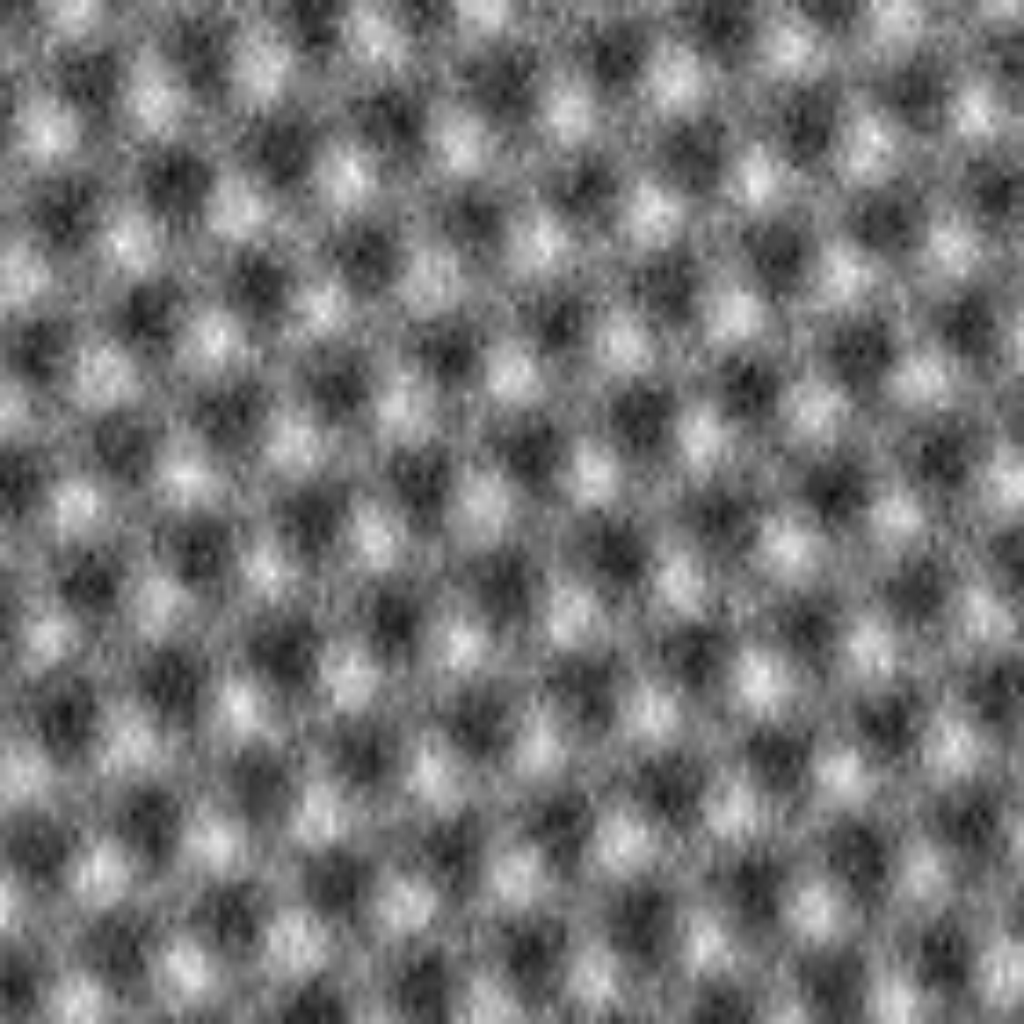

In [14]:
from torchvision.transforms import transforms
from PIL import Image
import torch
import random
import numpy as np

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
set_seed(40)
# image_path = "../PCA/train_pic/Sim_1T_256/train_1T_1.png"
# image_path = "../PCA/train_pic/Sim_1T_1024/train_1T_1.png"
image_path = "../PCA/train_pic/Sim_2H_256/train_2H_1.png"
image = Image.open(image_path).convert('RGB')
transform = transforms.RandomResizedCrop(
            size=(1024, 1024),  # Original size,
            scale=(0.1, 0.5),
            ratio=(0.75, 1.33),
            interpolation=transforms.InterpolationMode.BILINEAR
        )
transform(image)

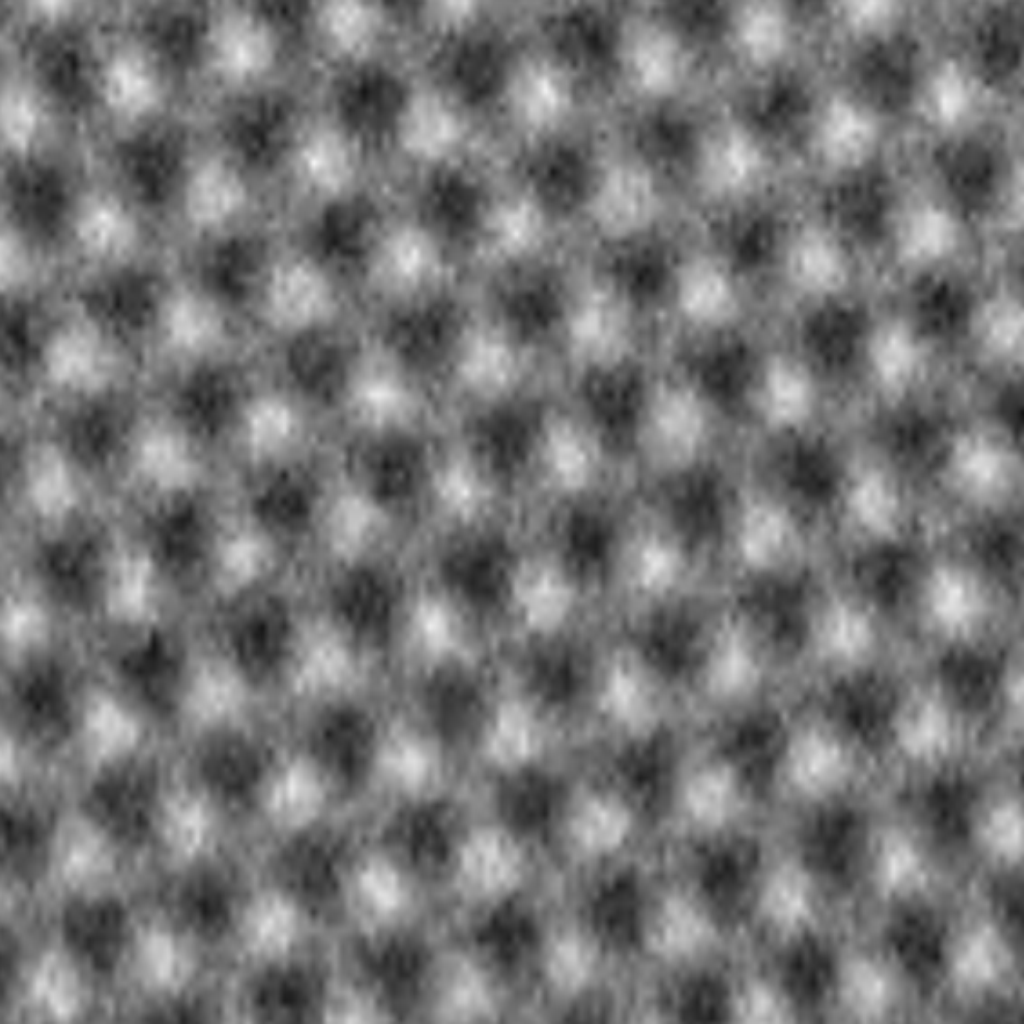

In [13]:
from torchvision.transforms import transforms
from PIL import Image
import torch
import random
import numpy as np

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
set_seed(40)
# image_path = "../PCA/train_pic/Sim_1T_256/train_1T_1.png"
# image_path = "../PCA/train_pic/Sim_1T_1024/train_1T_1.png"
image_path = "../PCA/train_pic/Sim_2H_256/train_2H_1.png"
image = Image.open(image_path).convert('RGB')
image_2 = image.resize((1024, 1024), Image.BILINEAR)
transform = transforms.RandomResizedCrop(
            size=(1024, 1024),  # Original size,
            scale=(0.1, 0.5),
            ratio=(0.75, 1.33),
            interpolation=transforms.InterpolationMode.BILINEAR
        )
transform(image_2)

In [45]:
# random seed
import random
random.seed(42)
a = random.uniform(0, 1)
a

0.6394267984578837

In [49]:
import torch
torch.initial_seed() %2**32

849938454

In [59]:
import torch
import logging

logging.basicConfig(level=logging.INFO)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [61]:
a = 'test'
print('print a')
print(f'print {a}')

print a
print test


In [64]:
from torchvision import transforms
from PIL import Image

image_path = "../PCA/train_pic/cat/cat_1.png"
image = Image.open(image_path).convert('RGB')
transform = transforms.ToTensor()
a = transform(image)


In [68]:
from torchvision import transforms
transform = transforms.Resize((1024,1024))
image_path = "../PCA/train_pic/cat/cat_1.png"
image = Image.open(image_path).convert('RGB')
a = transform(image)
a.size

(1024, 1024)

In [70]:
import os
image_paths = []
root_dir = '../PCA/train_pic/cat'
for img_name in os.listdir(root_dir):
    image_path = os.path.join(root_dir, img_name)
    image_paths.append(image_path)
image_paths


['../PCA/train_pic/cat/cat_1.png',
 '../PCA/train_pic/cat/cat_2.png',
 '../PCA/train_pic/cat/cat_4.png',
 '../PCA/train_pic/cat/cat_3.png']

In [76]:
from pathlib import Path
image_paths = []
a = Path('../PCA/train_pic/cat').glob('*.png')
list_a = list(a)
image_paths.extend(list_a)
image_paths

[PosixPath('../PCA/train_pic/cat/cat_1.png'),
 PosixPath('../PCA/train_pic/cat/cat_2.png'),
 PosixPath('../PCA/train_pic/cat/cat_4.png'),
 PosixPath('../PCA/train_pic/cat/cat_3.png')]

In [7]:
def test_func(a=1, b=None):
    return a, b
test = test_func(a=2)
test[1].__class__

NoneType

In [15]:
import torch
import torch.nn.functional as F
import numpy as np

student_logits = torch.randn(2, 3)           # (batch, classes)
teacher_logits = torch.randn(2, 3)           # (batch, classes)
student_log_probs = F.log_softmax(student_logits, dim=-1)
teacher_log_probs = F.softmax(teacher_logits, dim=-1)
loss = torch.sum(-teacher_log_probs * student_log_probs, dim=-1)
print(loss)
print(loss.mean())

tensor([1.6675, 1.2859])
tensor(1.4767)


In [3]:
import torch
import torch.nn.functional as F
device = torch.device('cuda')
torch.set_printoptions(profile="full", edgeitems=4,linewidth=75)
mask_1 = torch.rand(1, 4, 4, device=device) > 0.5
mask_2 = F.interpolate(mask_1.unsqueeze(-1).float(), size=(16,16), mode='nearest')  
mask_1

tensor([[[False,  True,  True, False],
         [ True, False,  True,  True],
         [False,  True, False,  True],
         [ True,  True,  True, False]]], device='cuda:0')

In [17]:
import torch
import torch.nn.functional as F
device = torch.device('cuda')
# torch.manual_seed(42)
torch.set_printoptions(profile="full", edgeitems=4,linewidth=75)
mask = torch.rand(2, 16, 8)
mask_1 = torch.rand(2, 4, 4) > 0.5
mask_indices = [torch.nonzero(~mask_1[b], as_tuple=False) for b in range(2)]
mask_indices_b = mask_indices[0]
# mask_2 = F.interpolate(mask_1.unsqueeze(-1).float(), size=(16,16), mode='nearest')  
linear_indices = mask_indices_b[:, 0]*4 + mask_indices_b[:, 1]
mask_patches = mask[0,linear_indices]
# print(mask)
# print(mask_1)
# print(mask_indices)
print(linear_indices)
print(mask_patches)


tensor([ 0,  2,  3,  5,  7,  8, 10, 12, 14])
tensor([[0.7952, 0.7563, 0.3258, 0.0772, 0.1225, 0.7466, 0.6474, 0.9129],
        [0.6652, 0.1535, 0.0081, 0.2834, 0.2847, 0.5548, 0.0900, 0.3059],
        [0.3291, 0.9096, 0.4853, 0.0097, 0.9382, 0.8116, 0.4730, 0.9560],
        [0.6832, 0.4758, 0.5108, 0.4674, 0.9563, 0.9765, 0.8405, 0.5415],
        [0.0046, 0.7493, 0.5109, 0.6071, 0.0876, 0.1462, 0.9191, 0.8763],
        [0.7329, 0.4043, 0.5945, 0.8628, 0.1939, 0.2694, 0.9222, 0.5424],
        [0.7224, 0.3106, 0.2513, 0.6483, 0.4703, 0.6919, 0.9467, 0.0934],
        [0.0787, 0.7320, 0.7946, 0.7745, 0.8002, 0.0075, 0.6080, 0.2413],
        [0.8354, 0.6386, 0.6408, 0.0671, 0.8868, 0.4695, 0.3410, 0.6576]])


In [18]:
import torch
import torch.nn.functional as F
device = torch.device('cuda')
# torch.manual_seed(42)
torch.set_printoptions(profile="full", edgeitems=4,linewidth=75)
mask_1 = torch.rand(1, 4, 4, device=device) > 0.5
mask_indices = [torch.nonzero(mask_1[0], as_tuple=False)]
torch.arange(16,device=device)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15],
       device='cuda:0')